<a href="https://colab.research.google.com/github/jnahMoch/revisedBookRecommender/blob/main/vector_search.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [48]:
!pip install langchain langchain-community langchain-openai langchain-chroma chromadb pandas python-dotenv

In [49]:
import os
import pandas as pd
from google.colab import userdata
from langchain_openai import OpenAIEmbeddings
from langchain_chroma import Chroma
from langchain_community.document_loaders import TextLoader
from langchain_text_splitters import CharacterTextSplitter

# ===================================================
# 1. SAFELY FETCH YOUR API KEY FROM COLAB SECRETS
# ===================================================
try:
    # This fetches the hidden key without printing it on the screen
    # Explicitly handle potential duplicated keys or internal newlines
    MY_API_KEY = userdata.get('OPENAI_API_KEY').split('\n')[0].strip()
    os.environ["OPENAI_API_KEY"] = MY_API_KEY
    print("✅ Securely fetched OpenAI API Key from Colab Secrets!")
except Exception as e:
    raise ValueError("Could not find 'OPENAI_API_KEY' in your Colab Secrets. Please check Step 1!")

✅ Securely fetched OpenAI API Key from Colab Secrets!


In [50]:
# ===================================================
# 2. LOAD & CLEAN DATASET
# ===================================================
print("🔄 Loading and cleaning dataset...")
books = pd.read_csv("books_with_categories_and_genre.csv")

# Fill missing items so string combining doesn't crash
books['title'] = books['title'].fillna('')
books['genre'] = books['genre'].fillna('')
books['simple_categories_binary'] = books['simple_categories_binary'].fillna('')
books['description'] = books['description'].fillna('')

# Build the custom tagged description where ISBN13 is always the FIRST word
books["tagged_description"] = (
    books["isbn13"].astype(str) + " " +
    books["title"] + " " +
    books["genre"] + " " +
    books["simple_categories_binary"] + " " +
    books["description"]
)

# Strip out empty strings
books = books[books["tagged_description"].str.strip() != ""]

# Save out to flat text loader file
books["tagged_description"].to_csv("tagged_description.txt", sep="\t", index=False, header=False)
print("   -> Created 'tagged_description.txt' successfully.")


🔄 Loading and cleaning dataset...
   -> Created 'tagged_description.txt' successfully.


In [51]:
# ===================================================
# 3. PARSE DOCUMENTS LINE-BY-LINE
# ===================================================
raw_documents = TextLoader("tagged_description.txt", encoding="utf-8").load()
text_splitter = CharacterTextSplitter(
    chunk_size=500, # Increased chunk size to reduce warnings
    chunk_overlap=0,
    separator="\n",
    strip_whitespace=True
)
documents = text_splitter.split_documents(raw_documents)
print(f"   -> Split texts into {len(documents)} distinct book blocks.")

   -> Split texts into 908 distinct book blocks.


In [52]:
# ===================================================
# 4. INITIALIZE CHROMA WITH VAULTED API KEY
# ===================================================
print("Initialized Vector Database")

embedding_model = OpenAIEmbeddings(api_key=MY_API_KEY)

db_books = Chroma.from_documents(
    documents,
    embedding=embedding_model
)

Initialized Vector Database


In [53]:
# ===================================================
# 5. CRASH-PROOF RECOMMENDATION FUNCTION
# ===================================================
def retrieve_semantic_recommendations(query: str, top_k: int = 10) -> pd.DataFrame:
    recs = db_books.similarity_search(query, k=50)
    books_list = []

    for i in range(len(recs)):
        try:
            content = recs[i].page_content.strip('"').strip()
            if not content:
                continue

            words = content.split()
            if len(words) > 0:
                raw_isbn = words[0].strip()
                # Clean datatype parsing to match integers
                clean_isbn = int(float(raw_isbn))
                books_list.append(clean_isbn)
        except (ValueError, IndexError):
            continue

    # Return matching results safely
    matched_books = books[books["isbn13"].isin(books_list)]
    return matched_books.head(top_k)

In [56]:
# ===================================================
# 6. RUN A TEST QUERY AUTOMATICALLY
# ===================================================
print("\n--- SAMPLE SEARCH RESULTS ---")
results = retrieve_semantic_recommendations("A suspenseful fiction murder mystery book", top_k=5)
display(results[['title','authors', 'genre', 'simple_categories_binary', 'average_rating']])



--- SAMPLE SEARCH RESULTS ---


,title,authors,genre,simple_categories_binary,average_rating
13,Murder in LaMut,Raymond E. Feist;Joel Rosenberg,Literature & Drama,fiction,3.70
25,Murder in Mesopotamia,Agatha Christie,Literature & Drama,fiction,3.89
28,Appointment with Death,Agatha Christie,Literature & Drama,fiction,3.86
29,Hallowe'en Party,Agatha Christie,Literature & Drama,fiction,3.66
34,A Murder is Announced,Agatha Christie,Literature & Drama,fiction,3.98


In [55]:
books.head()

,isbn13,isbn10,title,authors,categories,description,thumbnail,average_rating,num_pages,cleaned_description,simple_categories_binary,genre,tagged_description
0,9780002005883,0002005883,Gilead,Marilynne Robinson,Fiction,A NOVEL THAT READERS and critics have been eag...,http://books.google.com/books/content?id=KQZCP...,3.85,247.0,novel reader critic eagerly anticipating decad...,fiction,Literature & Drama,9780002005883 Gilead Literature & Drama fictio...
1,9780002261982,0002261987,Spider's Web,Charles Osborne;Agatha Christie,Fiction,A new 'Christie for Christmas' -- a full-lengt...,http://books.google.com/books/content?id=gA5GP...,3.83,241.0,new christie christmas fulllength novel adapte...,fiction,Literature & Drama,9780002261982 Spider's Web Literature & Drama ...
2,9780006163831,0006163831,The One Tree,Stephen R. Donaldson,Fiction,Volume Two of Stephen Donaldson's acclaimed se...,http://books.google.com/books/content?id=OmQaw...,3.97,479.0,volume two stephen donaldsons acclaimed second...,fiction,Literature & Drama,9780006163831 The One Tree Literature & Drama ...
3,9780006178736,0006178731,Rage of angels,Sidney Sheldon,Fiction,"A memorable, mesmerizing heroine Jennifer -- b...",http://books.google.com/books/content?id=FKo2T...,3.93,512.0,memorable mesmerizing heroine jennifer brillia...,fiction,Literature & Drama,9780006178736 Rage of angels Literature & Dram...
4,9780006280897,0006280897,The Four Loves,Clive Staples Lewis,Religion,Lewis' work on the nature of love divides love...,http://books.google.com/books/content?id=XhQ5X...,4.15,170.0,lewis work nature love divide love four catego...,nonfiction,Philosophy & Religion,9780006280897 The Four Loves Philosophy & Reli...


In [61]:
#Test here:

print("What kind of book are looking for?")
search_query = input("Type here: ")
results =  retrieve_semantic_recommendations(search_query, top_k=5)
display(results[['title','authors', 'genre', 'simple_categories_binary', 'average_rating', 'description']])

What kind of book are looking for?
Type here: pride and prejudice 


,title,authors,genre,simple_categories_binary,average_rating,description
44,"Beware, Princess Elizabeth",Carolyn Meyer,Literature & Drama,fiction,3.88,A matter of life and death - and the Throne of...
331,Treasure Box,Orson Scott Card,Literature & Drama,fiction,3.32,A shattering childhood tragedy left Quentin Fe...
446,Lady of Quality,Georgette Heyer,Literature & Drama,fiction,3.87,Independent and spirited. Miss Annis Wychwood ...
494,Collected Short Stories,Graham Greene,Literature & Drama,fiction,3.97,"Affairs, obsessions, ardours, fantasy, myth, l..."
539,Hunger,Lan Samantha Chang,Literature & Drama,fiction,3.89,A firstgeneration immigrant from China marries...


In [69]:
# Evaluation

evaluation_benchmarks = {
    "A story about a priest or preacher in a small town": [9780002005883], # Gilead
    "Agatha Christie style mystery play novelisation": [9780002261982],    # Spider's Web
    "Stephen Donaldson epic fantasy anti-hero trilogy": [9780006163831]   # The One Tree
}

def evaluate_vector_search(benchmarks, k=5):
    total_queries = len(benchmarks)
    hits = 0
    precision_scores = []

    print(f" Evaluating Vector Engine (Top K={k})")

    for query, true_isbns in benchmarks.items():
        results_df = retrieve_semantic_recommendations(query, top_k=k)
        predicted_isbns = results_df["isbn13"].tolist()

        has_hit = any(isbn in predicted_isbns for isbn in true_isbns)
        if has_hit:
            hits += 1

        matched_count = sum(1 for isbn in predicted_isbns if isbn in true_isbns)
        precision_scores.append(matched_count / k)

        print(f"Query: '{query}' -> {'✅ HIT' if has_hit else '❌ MISS'} (Precision: {matched_count/k:.2f})")

    print("FINAL IR PERFORMANCE METRICS")
    print(f"System Hit-Rate@{k}: {hits / total_queries:.2%}")
    print(f"Average Precision@{k}: {sum(precision_scores) / total_queries:.2%}")

In [64]:
evaluate_vector_search(evaluation_benchmarks, k=5)

=== Evaluating Vector Engine (Top K=5) ===
Query: 'A story about a priest or preacher in a small town' -> ✅ HIT (Precision: 0.20)
Query: 'Agatha Christie style mystery play novelisation' -> ✅ HIT (Precision: 0.20)
Query: 'Stephen Donaldson epic fantasy anti-hero trilogy' -> ✅ HIT (Precision: 0.20)

=== FINAL IR PERFORMANCE METRICS ===
System Hit-Rate@5: 100.00%
Average Precision@5: 20.00%


Metadata Alignment Audit for Query: 'Historical politics and biographical war documents'

 Discovered Genre Distribution:
genre
Biography & History      82.4%
Literature & Drama       11.8%
Academic & Humanities     5.9%
Name: proportion, dtype: object

 Discovered Binary Distribution:
simple_categories_binary
nonfiction    88.2%
fiction       11.8%
Name: proportion, dtype: object


/tmp/ipykernel_8852/180637176.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=results, x='genre', palette="Set3", order=results['genre'].value_counts().index)


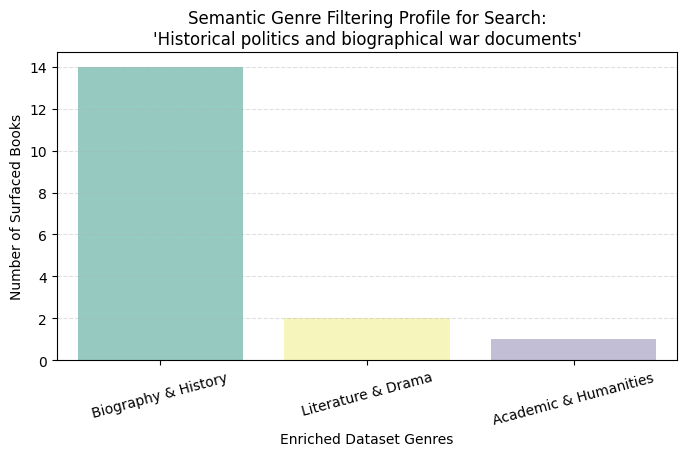

In [68]:
import matplotlib.pyplot as plt
import seaborn as sns

def audit_semantic_alignment(query, test_k=25):
    results = retrieve_semantic_recommendations(query, top_k=test_k)

    print(f"Metadata Alignment Audit for Query: '{query}'")
    print("\n Discovered Genre Distribution:")
    print(results['genre'].value_counts(normalize=True).map(lambda n: f"{n:.1%}"))

    print("\n Discovered Binary Distribution:")
    print(results['simple_categories_binary'].value_counts(normalize=True).map(lambda n: f"{n:.1%}"))

    plt.figure(figsize=(8, 4))
    sns.countplot(data=results, x='genre', palette="Set3", order=results['genre'].value_counts().index)
    plt.title(f"Semantic Genre Filtering Profile for Search:\n'{query}'")
    plt.ylabel("Number of Surfaced Books")
    plt.xlabel("Enriched Dataset Genres")
    plt.xticks(rotation=15)
    plt.grid(axis='y', linestyle='--', alpha=0.4)
    plt.show()

audit_semantic_alignment("Historical politics and biographical war documents", test_k=20)